<a href="https://colab.research.google.com/github/firewaterblood26-debug/Customer-Chrun-Prediction/blob/main/Customer_chrun_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Churn_Modelling.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

# Display descriptive statistics for numerical columns
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Drop irrelevant columns
df_prepared = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Separate features (X) and target (y)
X = df_prepared.drop('Exited', axis=1)
y = df_prepared['Exited']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing and split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform the training data, transform the test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed training data:", X_train_processed.shape)
print("Shape of processed testing data:", X_test_processed.shape)

Shape of processed training data: (8000, 13)
Shape of processed testing data: (2000, 13)


The data has been successfully preprocessed: irrelevant columns dropped, categorical variables one-hot encoded, and numerical features scaled. The dataset is now split into training and testing sets, ready for model building. Next, we can proceed with training different machine learning models.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets and binary classification
logistic_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_processed)
y_pred_proba_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_pred_proba_logistic)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")
print(f"ROC AUC Score: {roc_auc_logistic:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.8080
Precision: 0.5891
Recall: 0.1867
F1-Score: 0.2836
ROC AUC Score: 0.7748


The Logistic Regression model has been trained and evaluated. The results provide initial insights into its performance for predicting customer churn. We can compare these metrics with other models later to determine the best approach.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Gradient Boosting model
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_gbc = gbc_model.predict(X_test_processed)
y_pred_proba_gbc = gbc_model.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_pred_proba_gbc)

print("Gradient Boosting Classifier Model Performance:")
print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC AUC Score: {roc_auc_gbc:.4f}")

Gradient Boosting Classifier Model Performance:
Accuracy: 0.8690
Precision: 0.7821
Recall: 0.4939
F1-Score: 0.6054
ROC AUC Score: 0.8702


The Gradient Boosting Classifier has been trained and evaluated. We can now compare its performance metrics, particularly recall and F1-score, against the Logistic Regression model to see if we achieved an improvement.

First, let's check the class distribution to see if there's a significant class imbalance, which can affect recall.

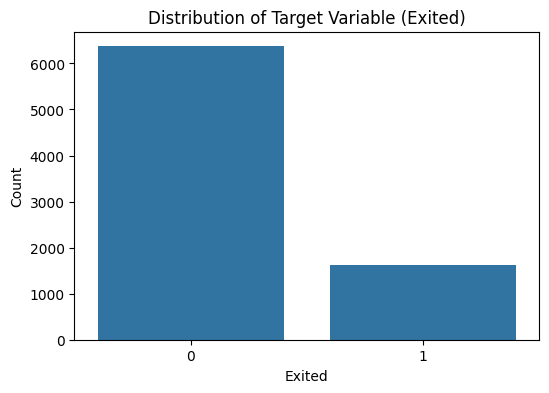

Class distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64

Percentage of churned customers:
 Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribution of Target Variable (Exited)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

print("Class distribution:\n", y_train.value_counts())
print("\nPercentage of churned customers:\n", y_train.value_counts(normalize=True))


The class distribution shows an imbalance, with significantly fewer churned customers (class 1). This imbalance can cause the model to be biased towards the majority class (class 0), leading to lower recall for the minority class (churned customers).

Now, let's proceed with hyperparameter tuning for the Gradient Boosting Classifier using `GridSearchCV` to optimize for `recall`.

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score, f1_score, make_scorer

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Define custom scoring for GridSearchCV to prioritize recall
scorer = make_scorer(recall_score)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid,
                           scoring=scorer, cv=3, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_processed, y_train)

# Get the best estimator
best_gbc = grid_search.best_estimator_

print("Best parameters found: ", grid_search.best_params_)

# Make predictions with the best model
y_pred_best_gbc = best_gbc.predict(X_test_processed)
y_pred_proba_best_gbc = best_gbc.predict_proba(X_test_processed)[:, 1]

# Evaluate the best model
accuracy_best_gbc = accuracy_score(y_test, y_pred_best_gbc)
precision_best_gbc = precision_score(y_test, y_pred_best_gbc)
recall_best_gbc = recall_score(y_test, y_pred_best_gbc)
f1_best_gbc = f1_score(y_test, y_pred_best_gbc)
roc_auc_best_gbc = roc_auc_score(y_test, y_pred_proba_best_gbc)

print("\nOptimized Gradient Boosting Classifier Model Performance (tuned for Recall):")
print(f"Accuracy: {accuracy_best_gbc:.4f}")
print(f"Precision: {precision_best_gbc:.4f}")
print(f"Recall: {recall_best_gbc:.4f}")
print(f"F1-Score: {f1_best_gbc:.4f}")
print(f"ROC AUC Score: {roc_auc_best_gbc:.4f}")


Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Optimized Gradient Boosting Classifier Model Performance (tuned for Recall):
Accuracy: 0.8600
Precision: 0.7276
Recall: 0.4988
F1-Score: 0.5918
ROC AUC Score: 0.8440


The hyperparameter tuning results show the performance of the optimized Gradient Boosting Classifier. You can compare these metrics with the previously obtained metrics to see if there's an improvement in recall and F1-score.

Given the class imbalance observed, using SMOTE (Synthetic Minority Over-sampling Technique) can help address this. SMOTE works by creating synthetic samples from the minority class, making the class distribution more balanced. This can lead to improved recall for the minority class.

In [9]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("Shape of original training data:", X_train_processed.shape)
print("Shape of resampled training data:", X_train_resampled.shape)
print("Class distribution after SMOTE:\n", y_train_resampled.value_counts())

Shape of original training data: (8000, 13)
Shape of resampled training data: (12740, 13)
Class distribution after SMOTE:
 Exited
1    6370
0    6370
Name: count, dtype: int64


Now that the training data is balanced using SMOTE, let's retrain the Gradient Boosting Classifier with the best parameters found earlier on this resampled data.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize a new Gradient Boosting Classifier with the best parameters
# We'll use the parameters found during the GridSearchCV for recall optimization
# {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

gbc_smote_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Train the model on the SMOTE-resampled data
gbc_smote_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_gbc_smote = gbc_smote_model.predict(X_test_processed)
y_pred_proba_gbc_smote = gbc_smote_model.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
accuracy_gbc_smote = accuracy_score(y_test, y_pred_gbc_smote)
precision_gbc_smote = precision_score(y_test, y_pred_gbc_smote)
recall_gbc_smote = recall_score(y_test, y_pred_gbc_smote)
f1_gbc_smote = f1_score(y_test, y_pred_gbc_smote)
roc_auc_gbc_smote = roc_auc_score(y_test, y_pred_proba_gbc_smote)

print("Gradient Boosting Classifier Model Performance (with SMOTE and tuned parameters):")
print(f"Accuracy: {accuracy_gbc_smote:.4f}")
print(f"Precision: {precision_gbc_smote:.4f}")
print(f"Recall: {recall_gbc_smote:.4f}")
print(f"F1-Score: {f1_gbc_smote:.4f}")
print(f"ROC AUC Score: {roc_auc_gbc_smote:.4f}")

Gradient Boosting Classifier Model Performance (with SMOTE and tuned parameters):
Accuracy: 0.8475
Precision: 0.6594
Recall: 0.5184
F1-Score: 0.5805
ROC AUC Score: 0.8485


The Gradient Boosting Classifier has been retrained using SMOTE-resampled data and the previously optimized hyperparameters. You can now compare these new performance metrics, especially recall and F1-score, with the previous results to assess the impact of SMOTE on handling the class imbalance.

### Comparing Model Performance
Let's compile all the performance metrics into a single DataFrame for a comprehensive comparison.

In [11]:
import pandas as pd

# Create a dictionary to store the metrics of each model
model_performance = {
    'Model': ['Logistic Regression', 'Gradient Boosting (Untuned)', 'Gradient Boosting (Tuned for Recall)', 'Gradient Boosting (SMOTE & Tuned)'],
    'Accuracy': [accuracy_logistic, accuracy_gbc, accuracy_best_gbc, accuracy_gbc_smote],
    'Precision': [precision_logistic, precision_gbc, precision_best_gbc, precision_gbc_smote],
    'Recall': [recall_logistic, recall_gbc, recall_best_gbc, recall_gbc_smote],
    'F1-Score': [f1_logistic, f1_gbc, f1_best_gbc, f1_gbc_smote],
    'ROC AUC Score': [roc_auc_logistic, roc_auc_gbc, roc_auc_best_gbc, roc_auc_gbc_smote]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)

# Display the DataFrame, formatted for better readability
display(performance_df.set_index('Model').round(4))

,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
Model,,,,,
Logistic Regression,0.8080,0.5891,0.1867,0.2836,0.7748
Gradient Boosting (Untuned),0.8690,0.7821,0.4939,0.6054,0.8702
Gradient Boosting (Tuned for Recall),0.8600,0.7276,0.4988,0.5918,0.8440
Gradient Boosting (SMOTE & Tuned),0.8475,0.6594,0.5184,0.5805,0.8485


### Visualizing Model Performance
To better understand the trade-offs, let's visualize these metrics.

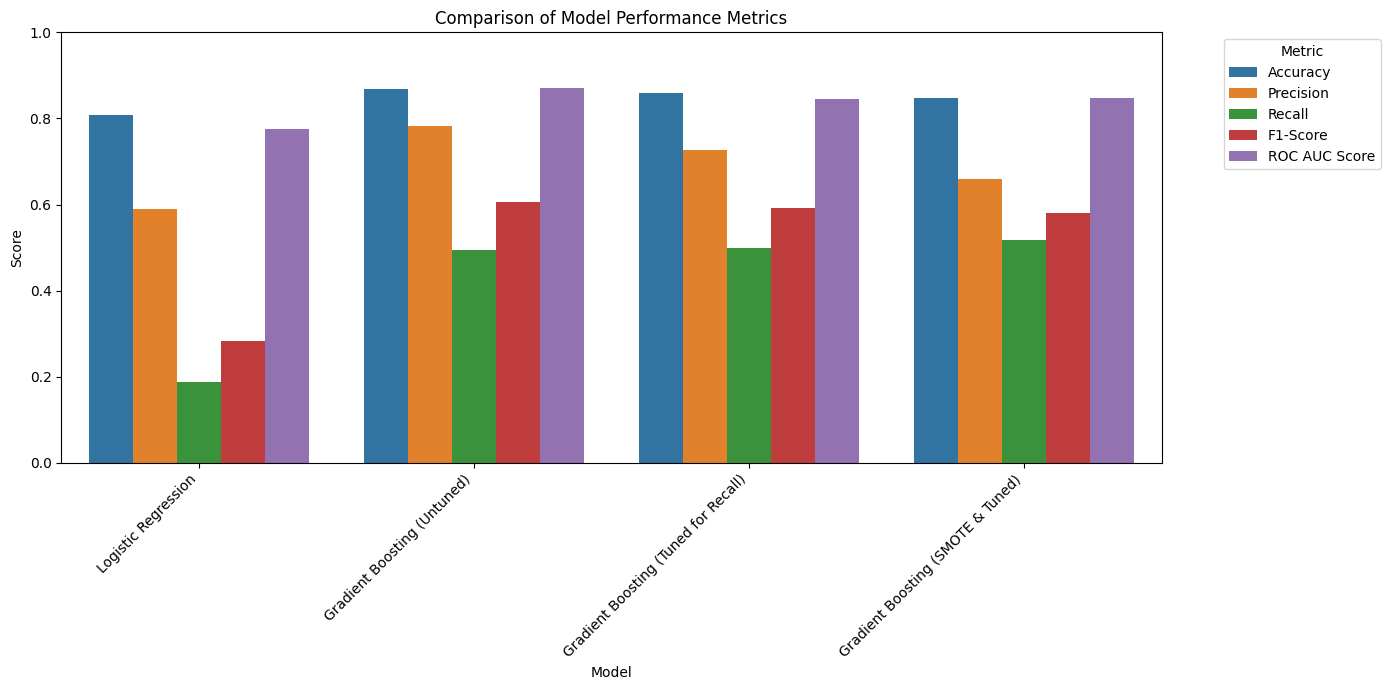

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
performance_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_melted)
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This comparison table and visualization should give you a clear overview of how each model performs across different metrics. From here, we can discuss which model best aligns with your business goals, considering the trade-offs between recall, precision, and overall accuracy. For example, if identifying as many churners as possible is paramount, the model with the highest recall would be preferred, even if its precision is slightly lower.